In [1]:
import sys
sys.path.append('/home/jimmy/Desktop/projects/notebooks/backup_beloved_code/python/')

import pandas as pd
import numpy as np
from missing_value_check import MSV_check
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix ,accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# no_id if true there would be no id
def preprocessing(DataFrame : pd.DataFrame , str_columns: list , test = False , no_id = True , test_size = 0.2):
    cop_DataFrame = DataFrame.copy()
    DataFrame_columns = cop_DataFrame.columns
    DataFrame = None

    if no_id:
        if 'id' in DataFrame_columns:
            cop_DataFrame.drop('id' , axis = 1 , inplace = True)


    if not test:
        X_columns = DataFrame_columns.difference(['Personality' , 'id'])
        train , valid = train_test_split(cop_DataFrame , test_size = test_size)    

        for col in str_columns:
            train[col] = np.where(pd.isna(train[col]) , np.nan, 
                                  np.where((train[col] == 'Yes') | (train[col] == 'Extrovert') , 1 , 0))
            
            valid[col] = np.where(pd.isna(valid[col]) , np.nan, 
                                  np.where((valid[col] == 'Yes') | (valid[col] == 'Extrovert') , 1 , 0))
        

        X_train = train[X_columns]
        X_valid = valid[X_columns]

        y_train = train['Personality']
        y_valid = valid['Personality']

        result = (X_train , X_valid , y_train , y_valid)
    

    else: 
        for col in str_columns:
            cop_DataFrame[col] = np.where(pd.isna(cop_DataFrame[col]) , np.nan, 
                         np.where((cop_DataFrame[col] == 'Yes') | (cop_DataFrame[col] == 'Extrovert') , 1 , 0))
            
            result = cop_DataFrame



    return result

we have 3 datasets. one is `train` that is generated by model that was trained on `original`. and test is our data we are given to predict for competition. the target is `Personality` column which is personality of a person, introvert or extrovert. and what are other columns are self-explanatory.

In [3]:
original = pd.read_csv('/run/media/jimmy/datasets/Extrovert vs. Introvert Behavior Data/original one/personality_dataset.csv')
train = pd.read_csv('/run/media/jimmy/datasets/Extrovert vs. Introvert Behavior Data/smaller one for competition/train.csv')
test = pd.read_csv('/run/media/jimmy/datasets/Extrovert vs. Introvert Behavior Data/smaller one for competition/test.csv')

X_train_original , X_valid_original , y_train_original , y_valid_original = preprocessing(DataFrame = original,
                                                                                          str_columns = ['Stage_fear' , 'Drained_after_socializing' , 'Personality'],
                                                                                          test_size = 0.15)

X_train , x_valid, y_train , y_valid = preprocessing(DataFrame = train , str_columns = ['Stage_fear' , 'Drained_after_socializing' , 'Personality'] , test_size = 0.15)
test = preprocessing(DataFrame = test , str_columns = ['Stage_fear' , 'Drained_after_socializing'] , test = True , no_id = False)

In [5]:
X_train_original.head()

,Drained_after_socializing,Friends_circle_size,Going_outside,Post_frequency,Social_event_attendance,Stage_fear,Time_spent_Alone
982,0.0,10.0,6.0,6.0,8.0,0.0,2.0
2254,1.0,1.0,2.0,1.0,2.0,1.0,5.0
1352,0.0,11.0,4.0,3.0,4.0,0.0,1.0
1934,0.0,15.0,3.0,3.0,7.0,0.0,2.0
2245,1.0,2.0,2.0,2.0,3.0,1.0,NaN


In [6]:
X_train_original.describe()

,Drained_after_socializing,Friends_circle_size,Going_outside,Post_frequency,Social_event_attendance,Stage_fear,Time_spent_Alone
count,2419.000000,2399.000000,2406.000000,2405.000000,2414.000000,2400.000000,2409.000000
mean,0.494419,6.270529,3.002909,3.555094,3.987158,0.498750,4.505604
std,0.500072,4.290505,2.251817,2.911760,2.912070,0.500103,3.461714
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,3.000000,1.000000,1.000000,2.000000,0.000000,2.000000
50%,0.000000,5.000000,3.000000,3.000000,3.000000,0.000000,4.000000
75%,1.000000,10.000000,5.000000,6.000000,6.000000,1.000000,8.000000
max,1.000000,15.000000,7.000000,10.000000,10.000000,1.000000,11.000000


In [7]:
X_train_original.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2465 entries, 982 to 2893
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Drained_after_socializing  2419 non-null   float64
 1   Friends_circle_size        2399 non-null   float64
 2   Going_outside              2406 non-null   float64
 3   Post_frequency             2405 non-null   float64
 4   Social_event_attendance    2414 non-null   float64
 5   Stage_fear                 2400 non-null   float64
 6   Time_spent_Alone           2409 non-null   float64
dtypes: float64(7)
memory usage: 154.1 KB


In [ ]:
Z = MSV_check(dataset = original , alpha = 0.05)
Z.check_it()

,not_missing,missing,missing_percentage(%),missing_value_type
Time_spent_Alone,2837.0,63.0,2.17,MCAR
Stage_fear,2827.0,73.0,2.52,MCAR
Social_event_attendance,2838.0,62.0,2.14,MCAR
Going_outside,2834.0,66.0,2.28,MCAR
Drained_after_socializing,2848.0,52.0,1.79,MNAR or MAR
Friends_circle_size,2823.0,77.0,2.66,MCAR
Post_frequency,2835.0,65.0,2.24,MCAR
Personality,2900.0,0.0,0.00,NaN


["['Social_event_attendance', 'Stage_fear', 'Personality'] affected Drained_after_socializing"]

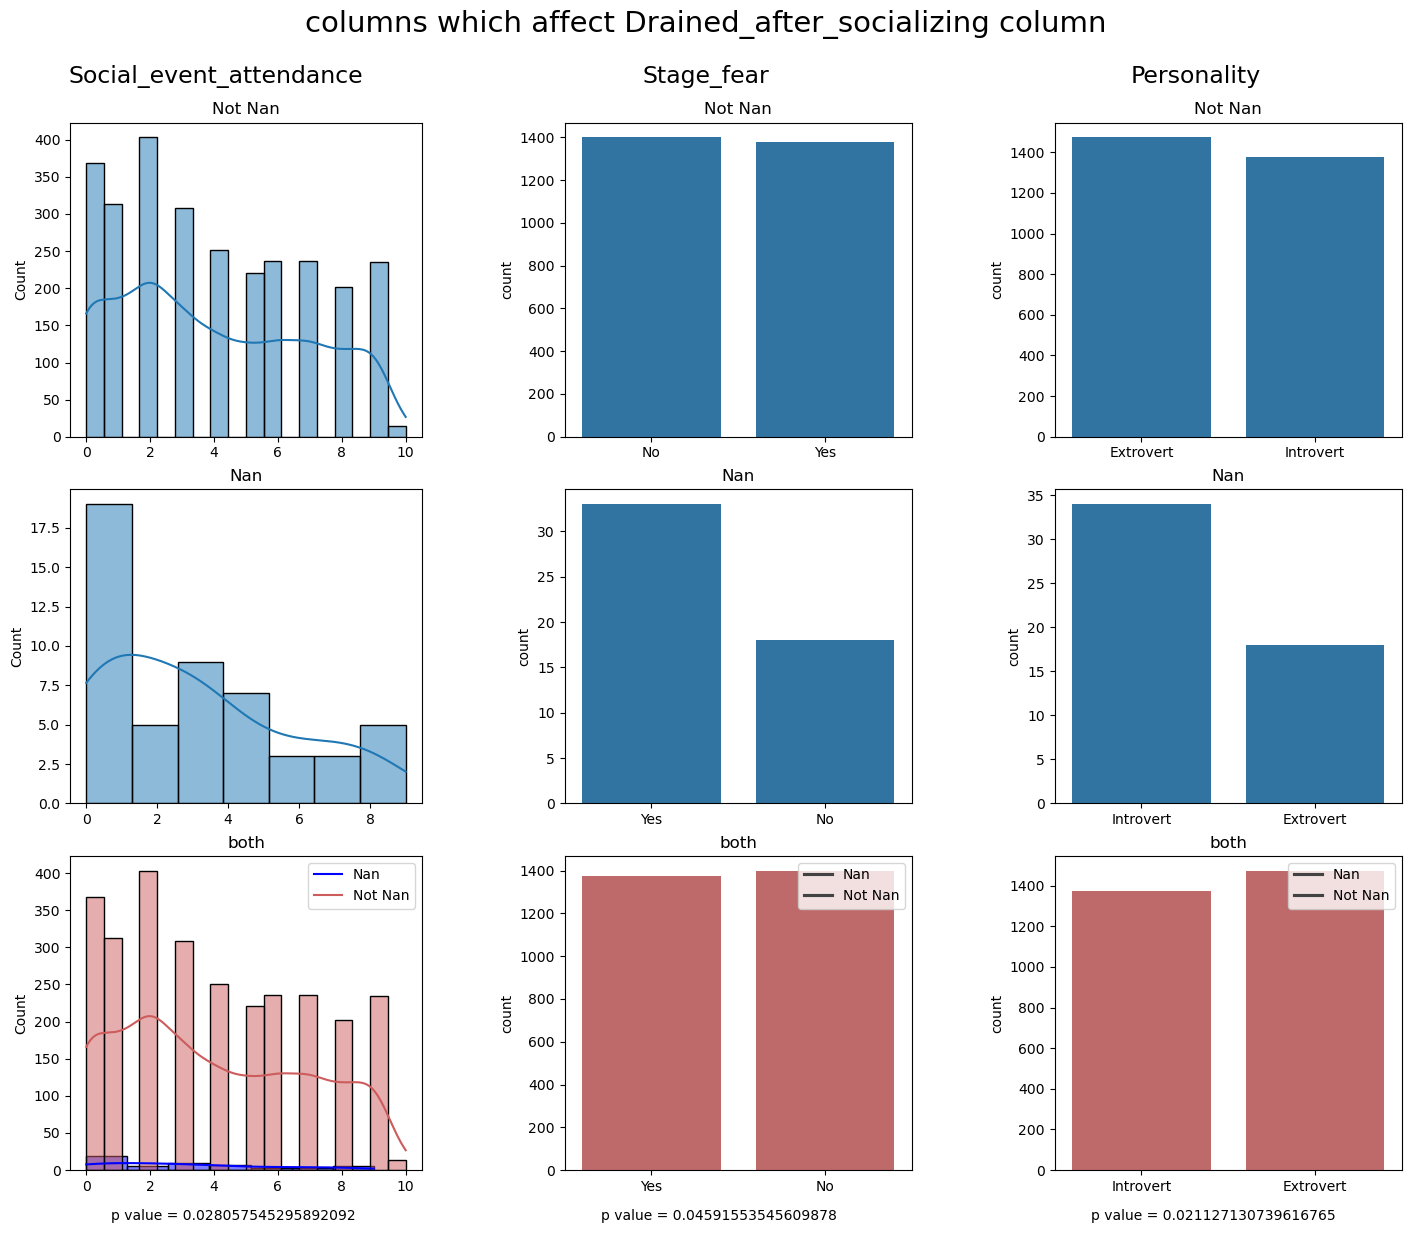

In [10]:
Z.show_proof()

In [ ]:
classifier = RandomForestClassifier()

model = classifier.fit(X = X_train_original , y = y_train_original)
model2 = classifier.fit(X = X_train , y = y_train)

predictions = model.predict(X = X_valid_original)
valid_pred = model2.predict(X = x_valid)

curious_pred = model.predict(X = x_valid)
interesting = model2.predict(X = X_valid_original)

# Evaluation Time!!!
***
this showed that there were no diff between our 2 models

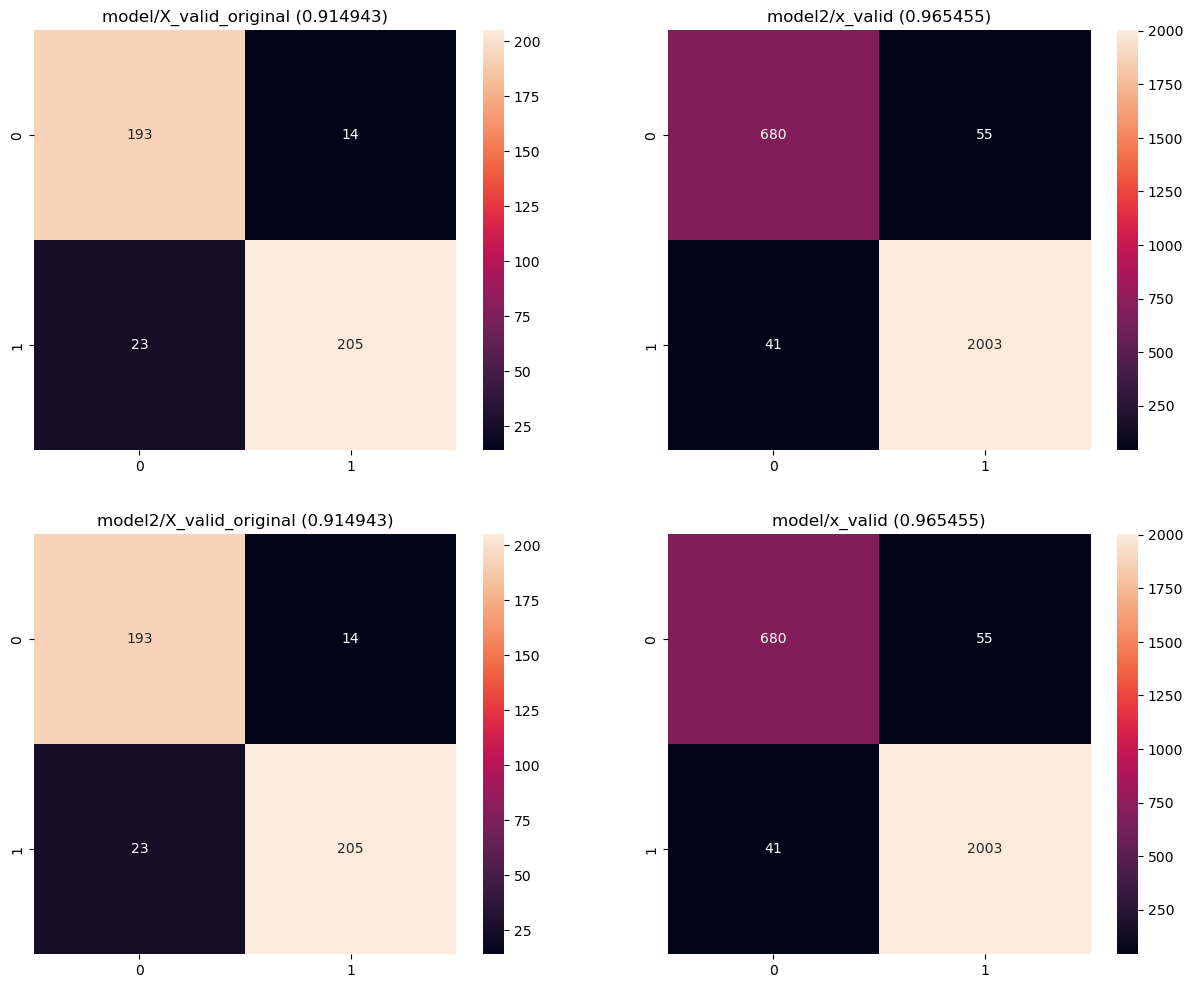

In [28]:
conf = confusion_matrix(y_true = y_valid_original , y_pred = predictions)
valid_conf = confusion_matrix(y_true = y_valid , y_pred = valid_pred)
curious_conf = confusion_matrix(y_true = y_valid , y_pred = curious_pred)
interesting_conf = confusion_matrix(y_true = y_valid_original , y_pred = interesting)

acc = accuracy_score(y_true = y_valid_original , y_pred = predictions)
valid_acc = accuracy_score(y_true = y_valid , y_pred = valid_pred)
curious_acc = accuracy_score(y_true = y_valid , y_pred = curious_pred)
interesting_acc = accuracy_score(y_true = y_valid_original , y_pred = interesting)

figure , [[ax1 , ax2] , [ax3 , ax4]] = plt.subplots(ncols = 2 , nrows = 2)
figure.set_figwidth(15)
figure.set_figheight(12)

ax1.set_title(f'model/X_valid_original ({round(acc , 6)})')
ax2.set_title(f'model2/x_valid ({round(valid_acc , 6)})')
ax3.set_title(f'model2/X_valid_original ({round(interesting_acc , 6)})')
ax4.set_title(f'model/x_valid ({round(curious_acc , 6)})')

sns.heatmap(conf , annot = True , fmt = '.0f' , ax = ax1)
sns.heatmap(valid_conf , annot = True , fmt = '.0f' , ax = ax2)
sns.heatmap(interesting_conf , annot = True , fmt = '.0f' , ax = ax3)
sns.heatmap(curious_conf , annot = True , fmt = '.0f' , ax = ax4)

plt.show()

# Test Time!!!
***
and the score was 0.974089

In [ ]:
pred = model.predict(test[X_train.columns])
str_pred = np.where(pred == 1 , 'Extrovert' , 'Introvert')
concatenated = pd.concat([test['id'] , pd.Series(str_pred , name = 'Personality')] , axis = 1)
concatenated.set_index('id' , inplace = True)
concatenated.to_csv('/run/media/jimmy/datasets/Extrovert vs. Introvert Behavior Data/smaller one for competition/submission.csv')